# Import libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [2]:
df = pd.read_csv("cleaned_titanic.csv")

# Basic Inspection 

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [9]:
df.shape

(891, 11)

In [11]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

# Descriptive Statistics

In [13]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
df['Age'].mean()

29.36158249158249

In [17]:
df['Fare'].median()

14.4542

In [19]:
df['PassengerId'].count()

891

# Survial Analysis 

In [21]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

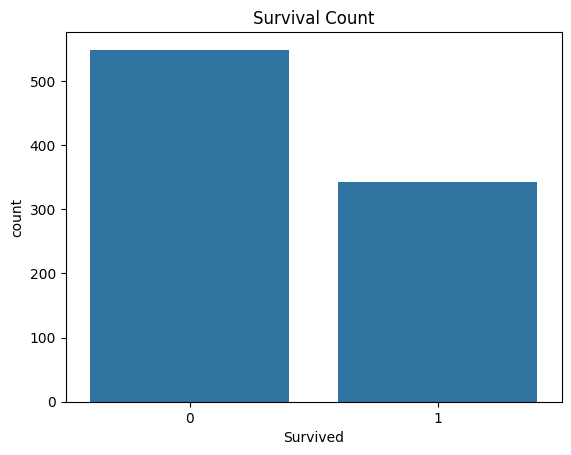

In [23]:
sns.countplot(x = 'Survived', data = df)
plt.title("Survival Count")
plt.show()

#### **- Most passengers did not survive**

# Gender Analysis 

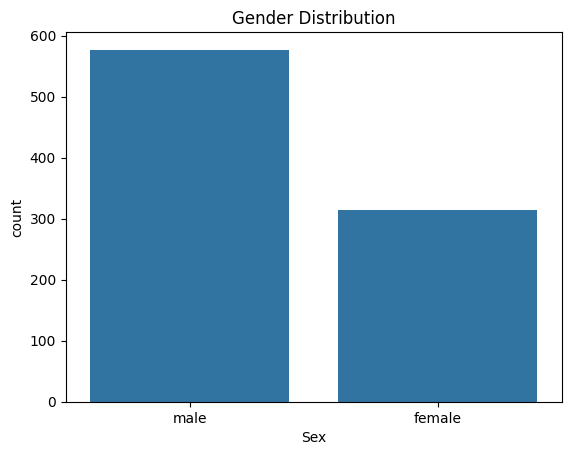

In [27]:
sns.countplot(x = 'Sex', data = df)
plt.title("Gender Distribution")
plt.show()

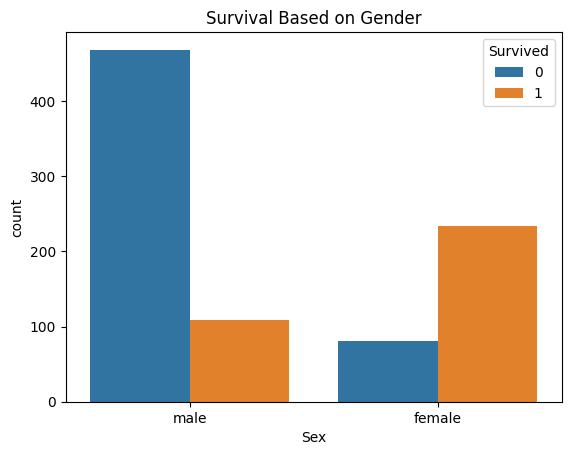

In [31]:
sns.countplot(x = 'Sex', hue = 'Survived' ,data = df)
plt.title("Survival Based on Gender")
plt.show()

#### **- Female passengers had higher survival rates compared to males**

# Age Distribution 

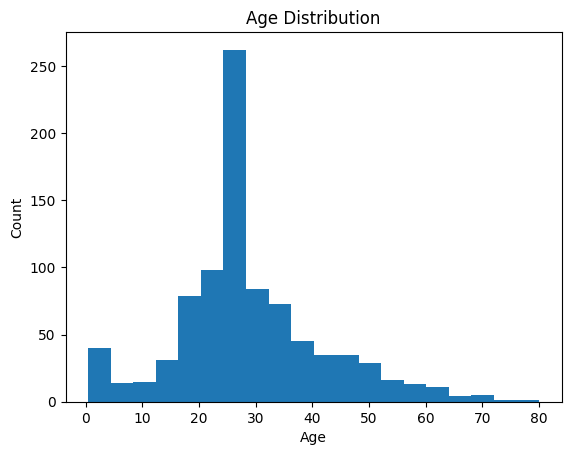

In [38]:
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

#### **- Most passengers were between 20–40 years old**

# Fare Distribution

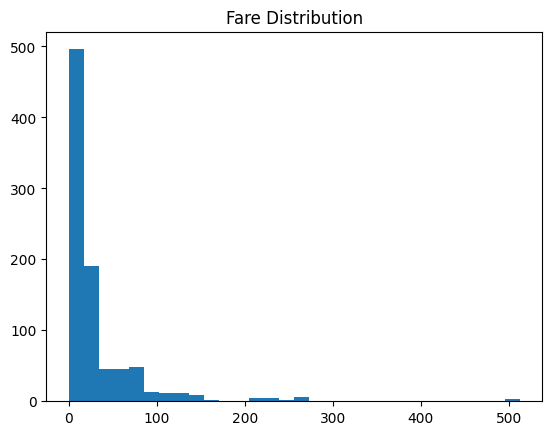

In [41]:
plt.hist(df["Fare"], bins=30)
plt.title("Fare Distribution")
plt.show()

#### **- Fare distribution is right-skewed**

# Outlier Detection

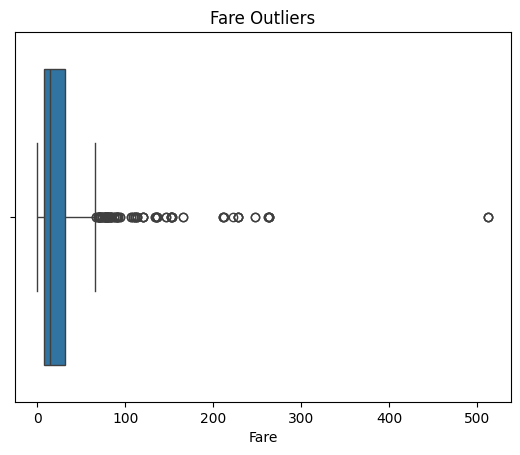

In [44]:
sns.boxplot(x=df["Fare"])
plt.title("Fare Outliers")
plt.show()

#### **- Several extreme fare values are present as outliers**

# Passenger Class Analysis

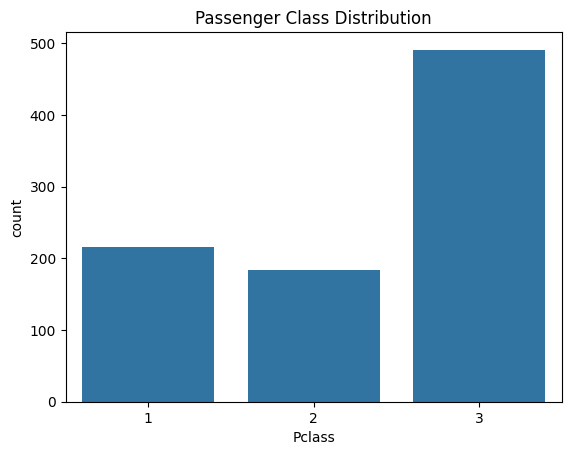

In [47]:
sns.countplot(x="Pclass", data=df)
plt.title("Passenger Class Distribution")
plt.show()

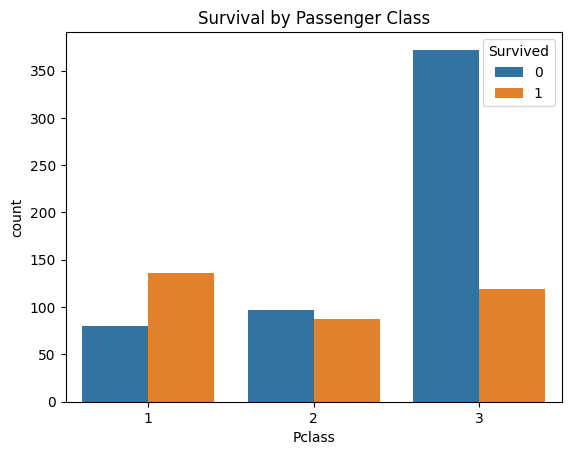

In [49]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

#### **- First-class passengers had better survival rates**

# correlation Analysis

In [53]:
corr = df.corr(numeric_only=True)
corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


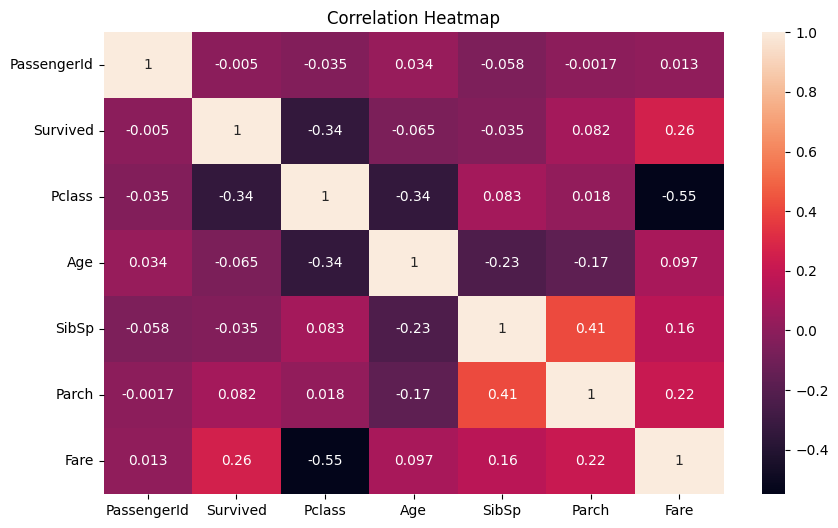

In [55]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

#### **- Passenger class and fare show correlation with survival**

# Scatter Plot

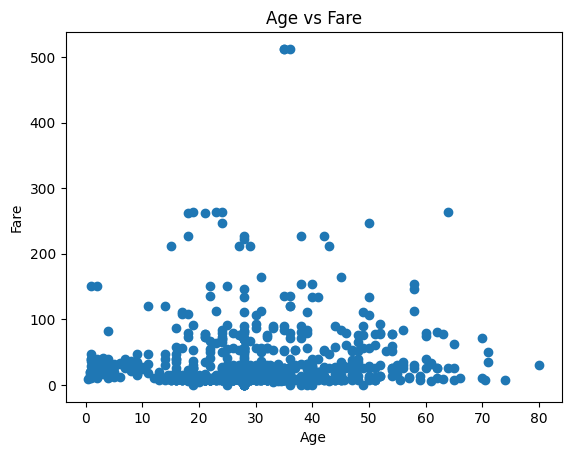

In [58]:
plt.scatter(df["Age"], df["Fare"])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare")
plt.show()

#### **- Higher fare passengers are spread across different age groups**

# Categorical Analysis

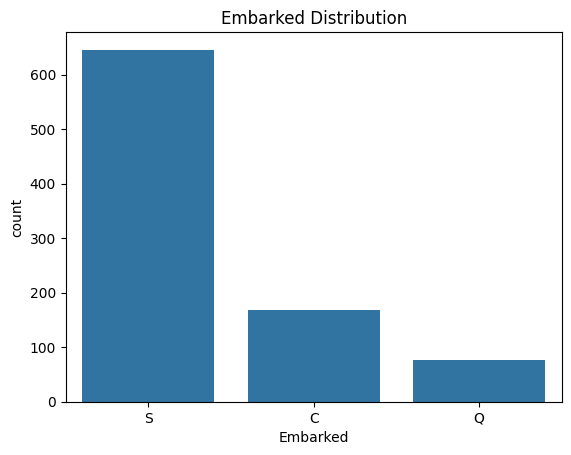

In [61]:
sns.countplot(x="Embarked", data=df)
plt.title("Embarked Distribution")
plt.show()

#### **- Most passengers boarded from Southampton** 

Key Insights:

1. Female passengers had higher survival rates.
2. First-class passengers survived more often.
3. Fare distribution contains outliers.
4. Most passengers were young adults.
5. Survival was influenced by passenger class and gender.

Conclusion:

- Exploratory Data Analysis was successfully performed on the Titanic dataset.
- The analysis identified important patterns, distributions, outliers, and relationships between variables.
- Gender and passenger class strongly influenced survival rates.
- The dataset is now well understood and ready.